In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
applications = pd.read_csv(
    "../data/applications_cleaned.csv",
    low_memory=False
)

loans = pd.read_csv("../data/loans_cleaned.csv")
branches = pd.read_csv("../data/branches_cleaned.csv")

In [3]:
applications['Application_Date'] = pd.to_datetime(
    applications['Application_Date'],
    errors='coerce'
)

In [4]:
applications['Application_Date'].dtype

dtype('<M8[us]')

In [5]:
approved_apps = applications[
    applications['Approval_Status'].str.lower() == 'approved'
].copy()

In [6]:
monthly_approved = approved_apps.groupby(
    approved_apps['Application_Date'].dt.to_period('M')
).size()

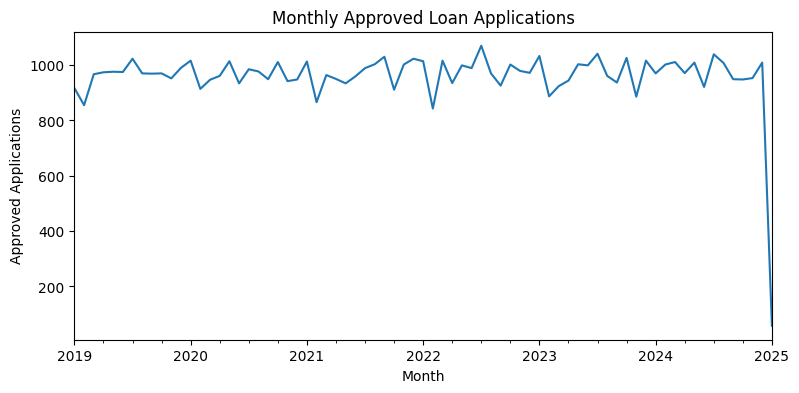

In [7]:
monthly_approved.plot(kind='line', figsize=(9,4))
plt.title("Monthly Approved Loan Applications")
plt.xlabel("Month")
plt.ylabel("Approved Applications")
plt.show()

In [8]:
monthly_approved.sort_values(ascending=False).head()

Application_Date
2022-07    1070
2023-07    1041
2024-07    1039
2023-01    1033
2021-09    1030
Freq: M, dtype: int64

In [9]:
region_efficiency = branches.groupby('Region').agg({
    'Total_Active_Loans': 'sum',
    'Delinquent_Loans': 'sum'
})

region_efficiency['Delinquency_Ratio'] = (
    region_efficiency['Delinquent_Loans'] /
    region_efficiency['Total_Active_Loans']
)

region_efficiency

,Total_Active_Loans,Delinquent_Loans,Delinquency_Ratio
Region,,,
Central,8715,994,0.114056
East,8929,756,0.084668
North,11965,1504,0.125700
Northeast,5174,487,0.094124
South,9235,846,0.091608
West,6861,441,0.064276


### Task 11 – Loan Disbursement Efficiency Insights

- Approved loan volumes fluctuate over time, indicating varying processing loads
- Peak approval periods may lead to operational bottlenecks
- Regions with higher delinquency ratios may face processing or monitoring inefficiencies
- Improving capacity planning during peak periods can enhance disbursement efficiency